# SE4050 Deep Learning Assignment
## Notebook 5: ResNet50 Transfer Learning
### Brain Tumor MRI Classification: Model 3 of 4

**Architecture**: ResNet50 pretrained on ImageNet-1K with a custom classification head  
**Training strategy**: Two-phase: feature extraction followed by layer4 fine-tuning  
**Prerequisite**: Execute `02_Preprocessing.ipynb` before this notebook.

## Section 0: Environment Setup

In [ ]:
# ==============================================================================
# 1. SYSTEM AND BACKEND CONFIGURATION
# ==============================================================================
import os

os.environ['KERAS_BACKEND'] = 'torch'

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ==============================================================================
# 2. CORE SCIENTIFIC AND MACHINE LEARNING LIBRARIES
# ==============================================================================
import json
import time
import random
import warnings
from pathlib import Path

# NumPy: Foundational array computing library for handling preprocessed image matrices.
import numpy as np

# Matplotlib & Seaborn: Comprehensive plotting libraries for loss curves, ROC, and confusion matrices.
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch Deep Learning Framework:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# Scikit-Learn Evaluation Utilities:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

# Suppress non-critical runtime user warnings for clean notebook presentation
warnings.filterwarnings('ignore')

# ==============================================================================
# 3. REPRODUCIBILITY AND DETERMINISTIC SEEDING
# ==============================================================================
# Setting an identical pseudo-random number generator (PRNG) seed guarantees that
# batch order, weight initialisation, and data shuffling remain exactly reproducible.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Enforce deterministic CUDA convolution algorithms if an NVIDIA GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ==============================================================================
# 4. HARDWARE ACCELERATION DETECTION
# ==============================================================================
# Automatically route tensor computations to CUDA if an NVIDIA GPU is present; fallback to CPU otherwise.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Compute device : {DEVICE}')
if DEVICE.type == 'cuda':
    # Query the primary GPU hardware identifier (e.g., NVIDIA GeForce RTX 4050 Laptop GPU)
    print(f'GPU model      : {torch.cuda.get_device_name(0)}')

# ==============================================================================
# 5. DIRECTORY STRUCTURE SETUP
# ==============================================================================
# Paths for input preprocessed artifacts, model checkpoint storage, and evaluation metrics
DATA_DIR  = Path('preprocessed_data')
MODEL_DIR = Path('saved_models') / 'ResNet50'
RES_DIR   = Path('results')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# 6. EXPERIMENTAL HYPERPARAMETERS & TWO-STAGE TRAINING STRATEGY
# ==============================================================================
# Batch Size: 32 balances GPU memory footprint (fitting within 6GB VRAM) and gradient estimation stability.
BATCH_SIZE    = 32
PHASE1_EPOCHS = 30  # Provides sufficient headroom for head convergence
PHASE2_EPOCHS = 50  # Allows deep fine-tuning and learning rate decay
LR_PHASE1     = 1e-4   # Phase 1: High learning rate for training newly initialized classification head
LR_PHASE2     = 1e-5   # Phase 2: Conservative learning rate to preserve early layer feature extractors
PATIENCE_P1   = 5   # Early stopping patience for Phase 1
PATIENCE_P2   = 7  # Early stopping patience for Phase 2
MODEL_NAME    = 'ResNet50'

print(f'Phase 1 : {PHASE1_EPOCHS} epochs @ LR={LR_PHASE1}')
print(f'Phase 2 : {PHASE2_EPOCHS} epochs @ LR={LR_PHASE2}')


Compute device : cuda
GPU model      : NVIDIA GeForce RTX 4050 Laptop GPU
Phase 1 : 30 epochs @ LR=0.0001
Phase 2 : 50 epochs @ LR=1e-05


## Section 1: Load Preprocessed Data

In [15]:
# ==============================================================================
# 1. LOAD PREPROCESSED NUMPY ARRAYS
# ==============================================================================
# Load standardized, partitioned arrays created by 02_Preprocessing.ipynb.
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val   = np.load(DATA_DIR / 'X_val.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

# ==============================================================================
# 2. CLASS METADATA AND COST-SENSITIVE CLASS WEIGHTS
# ==============================================================================
# Load balanced class weights computed using scikit-learn's inverse frequency formula: weight_c = N_total / (N_classes * N_c)

class_weights_arr    = np.load(DATA_DIR / 'class_weights.npy')
CLASS_NAMES          = np.load(DATA_DIR / 'class_names.npy', allow_pickle=True).tolist()
NUM_CLASSES          = len(CLASS_NAMES)

# Distinct aesthetic color palette assigned to each class for consistent cross-notebook reporting
CLASS_COLORS         = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

# Convert class weights to a float tensor and allocate directly to the active compute device (GPU/CPU)
class_weights_tensor = torch.FloatTensor(class_weights_arr).to(DEVICE)

# ==============================================================================
# 3. IMAGENET STANDARDIZATION CONSTANTS
# ==============================================================================
# The pre-trained ResNet50 backbone was optimized on ImageNet using channel-wise mean
RESNET_MEAN = [0.485, 0.456, 0.406]
RESNET_STD  = [0.229, 0.224, 0.225]

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'Classes: {CLASS_NAMES}')
print(f'ImageNet normalisation: mean={RESNET_MEAN}, std={RESNET_STD}')


X_train: (2284, 224, 224, 3) | X_val: (490, 224, 224, 3) | X_test: (490, 224, 224, 3)
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
ImageNet normalisation: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


## Section 2: Dataset and DataLoaders

In [16]:
# ==============================================================================
# 1. PYTORCH DATASET WRAPPER WITH DYNAMIC AUGMENTATION
# ==============================================================================
class MRIDatasetResNet(Dataset):
    """
    Custom PyTorch Dataset class encapsulating brain MRI NumPy arrays.

    Implements stochastic on-the-fly data augmentation for training samples
    while maintaining strictly deterministic tensor conversion for validation and testing.
    """

    # Dynamic Augmentation Pipeline (Applied EXCLUSIVELY to Training Images):
    TRAIN_TRANSFORMS = T.Compose([
        T.ToPILImage(),
        T.RandomRotation(degrees=40),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.3),
        T.RandomAffine(degrees=0, translate=(0.15, 0.15), shear=20, scale=(0.8, 1.2)),
        T.ColorJitter(brightness=0.2, contrast=0.15),
        T.ToTensor(),
        T.Normalize(mean=RESNET_MEAN, std=RESNET_STD),  # Required for ResNet50 inputs
    ])

    # Deterministic Evaluation Pipeline (Validation and Test Sets ONLY):
    # Strictly avoids synthetic distortions to guarantee an unbiased, true clinical performance measurement.
    EVAL_TRANSFORMS = T.Compose([
        T.ToPILImage(),
        T.ToTensor(),
        T.Normalize(mean=RESNET_MEAN, std=RESNET_STD),
    ])

    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        # Convert [0.0, 1.0] float32 arrays back to uint8 [0, 255] for PIL transform compatibility
        self.X = (X * 255).astype(np.uint8)
        self.y = y.astype(np.int64)
        # Select active transform based on dataset role (training vs validation/test)
        self.transform = self.TRAIN_TRANSFORMS if augment else self.EVAL_TRANSFORMS

    def __len__(self) -> int:
        """Return total number of samples in the partition."""
        return len(self.X)

    def __getitem__(self, idx: int):
        """Retrieve transformed image tensor and integer label for batch collation."""
        return self.transform(self.X[idx]), self.y[idx]


# ==============================================================================
# 2. PYTORCH DATALOADER INITIALISATION
# ==============================================================================
# Generator seeded with RANDOM_SEED ensures reproducible batch shuffling across epochs.
g = torch.Generator().manual_seed(RANDOM_SEED)

# Training DataLoader: shuffle=True ensures mini-batches are stochastically permuted each epoch.
# pin_memory=True accelerates tensor transfer from host CPU RAM to GPU VRAM via page-locked memory.
train_loader = DataLoader(
    MRIDatasetResNet(X_train, y_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, generator=g, pin_memory=True
)

# Validation DataLoader: shuffle=False maintains deterministic evaluation order for early stopping.
val_loader   = DataLoader(
    MRIDatasetResNet(X_val,   y_val,   augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

# Test DataLoader: Evaluated once at the conclusion of training on unseen clinical test images.
test_loader  = DataLoader(
    MRIDatasetResNet(X_test,  y_test,  augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print('DataLoaders ready.')


DataLoaders ready.


## Section 3: ResNet50 Architecture

### Design Rationale

ResNet50 uses **bottleneck residual blocks** composed of three convolutions (1x1, 3x3, 1x1),
where the 1x1 layers reduce and then restore the channel dimension, making computation
feasible for 50 layers. The skip connection adds the block input directly to the output,
enabling gradients to flow freely backwards through the entire network.

The model is divided into five stages:
- `conv1`, `bn1`, `relu`, `maxpool`: Stem (initial feature extraction)
- `layer1`: Stage 1 — 3 bottleneck blocks (64 channels)
- `layer2`: Stage 2 — 4 bottleneck blocks (128 channels)
- `layer3`: Stage 3 — 6 bottleneck blocks (256 channels)
- `layer4`: Stage 4 — 3 bottleneck blocks (512 x 4 = 2048 channels)  <-- unfrozen in Phase 2

Our fine-tuning strategy unfreezes `layer4` only, which encodes high-level semantic
representations most relevant to distinguishing tumor morphology. Earlier layers
encode general textures and edges that transfer well without modification.

In [17]:
# ==============================================================================
# 1. RESNET50 TRANSFER LEARNING ARCHITECTURE
# ==============================================================================
class ResNet50TransferModel(nn.Module):
    """
    ResNet50 Deep Residual Network adapted for 4-class Brain Tumor MRI Classification.

    Architectural Foundation:
    - Backbone: ResNet-50 deep residual network comprising 50 convolutional layers.
      Residual skip connections (identity shortcuts: F(x) + x) eliminate the vanishing
      gradient problem, enabling smooth gradient flow across deep bottleneck blocks.
    - Feature Extractor: 4 residual stages (layer1 to layer4) with 3-layer bottleneck
      blocks (1x1 conv dimension reduction -> 3x3 conv -> 1x1 conv dimension expansion).
    - Global Average Pooling: Aggregates spatial dimensions (7x7) into a single 2048-d vector,
      drastically reducing model parameters and mitigating overfitting compared to flattening.
    - Custom Classification Head:
        Linear(2048 -> 512) -> BatchNorm1d -> ReLU -> Dropout(0.5)
        Linear(512  -> 256) -> ReLU -> Dropout(0.4)
        Linear(256  -> 4)
    """

    def __init__(self, num_classes: int = 4, freeze_base: bool = True):
        super().__init__()

        # Instantiate ResNet50 with official ImageNet-1K pre-trained weights (IMAGENET1K_V1)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Truncate the architecture: strip the original 1000-class avgpool and fc layers.
        # resnet.children() returns:
        # [0] conv1, [1] bn1, [2] relu, [3] maxpool,
        # [4] layer1 (256 ch), [5] layer2 (512 ch), [6] layer3 (1024 ch), [7] layer4 (2048 ch)
        # Using [:-2] preserves all convolutional stages up to the 2048-channel output.
        self.backbone        = nn.Sequential(*list(resnet.children())[:-2])

        # Global Average Pooling collapses (N, 2048, 7, 7) feature maps to (N, 2048, 1, 1)
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Phase 1: Freeze all backbone parameters so their pre-trained weights remain unchanged
        if freeze_base:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Custom Top Classification Head designed for regularized multi-class MRI prediction
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),    # Normalizes feature activations to prevent internal covariate shift
            nn.ReLU(inplace=True),  # Non-linear activation function
            nn.Dropout(0.5),        # Stochastically drops 50% of activations to prevent co-adaptation
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),        # Secondary regularisation layer
            nn.Linear(256, num_classes), # Final unnormalized class logits (Glioma, Meningioma, No Tumor, Pituitary)
        )

        # Xavier (Glorot) Uniform Initialisation for linear layers in the custom head.
        # Ensures activation variances remain stable throughout forward and backward passes.
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward inference path through backbone, global pooling, and classification head."""
        x = self.backbone(x)          # Input (N, 3, 224, 224) -> Output (N, 2048, 7, 7)
        x = self.global_avg_pool(x)   # Output (N, 2048, 1, 1)
        return self.classifier(x)     # Output unnormalized logits (N, 4)

    def unfreeze_layer4(self):
        """
        Selectively unfreeze layer4 (the final bottleneck convolutional stage) for Phase 2 fine-tuning.

        Architecture index mapping in self.backbone Sequential:
          0: conv1, 1: bn1, 2: relu, 3: maxpool, 4: layer1, 5: layer2, 6: layer3, 7: layer4
        layer4 is the final element (self.backbone[-1]), containing 14.9 million parameters.
        """
        for param in self.backbone[-1].parameters():
            param.requires_grad = True
        unfrozen = sum(p.numel() for p in self.backbone[-1].parameters())
        print(f'layer4 unfrozen: {unfrozen:,} parameters enabled for training.')


# ==============================================================================
# 2. MODEL INITIALISATION AND SHAPE VERIFICATION
# ==============================================================================
# Instantiate model on active hardware device (GPU RTX 4050)
model = ResNet50TransferModel(num_classes=NUM_CLASSES, freeze_base=True).to(DEVICE)

# Calculate total and trainable parameter counts
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters            : {total_p:,}')
print(f'Trainable parameters (Ph.1) : {trainable_p:,}')

# Perform mock forward pass with dummy tensor to verify dimension compatibility
with torch.no_grad():
    out = model(torch.randn(2, 3, 224, 224).to(DEVICE))
print(f'Forward pass check          : (2,3,224,224) -> {tuple(out.shape)}')


Total parameters            : 24,690,500
Trainable parameters (Ph.1) : 1,182,468
Forward pass check          : (2,3,224,224) -> (2, 4)


## Section 4: Training Utilities

In [18]:
# ==============================================================================
# 1. EPOCH TRAINING UTILITY
# ==============================================================================
def train_epoch(model, loader, criterion, optimizer, device):
    """
    Execute one complete training epoch over the training partition.

    Steps per mini-batch:
      1. Transfer images and labels to device (GPU).
      2. Clear prior gradients via optimizer.zero_grad().
      3. Compute forward pass logits and categorical cross-entropy loss.
      4. Backpropagate gradients via loss.backward().
      5. Apply gradient clipping (norm <= 1.0) to prevent exploding gradients.
      6. Update model weights via optimizer.step().
      7. Accumulate running loss and correct prediction counts.
    """
    model.train()  # Enable Dropout and BatchNorm tracking
    ls, cor, tot = 0.0, 0, 0

    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()

        # Forward pass
        logits = model(X_b)
        loss   = criterion(logits, y_b)

        # Backward propagation
        loss.backward()

        # Gradient clipping prevents unstable large parameter updates
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer parameter update
        optimizer.step()

        # Metric tracking
        ls  += loss.item() * len(y_b)
        cor += (logits.argmax(1) == y_b).sum().item()
        tot += len(y_b)

    return ls / tot, cor / tot


# ==============================================================================
# 2. DETERMINISTIC EVALUATION UTILITY
# ==============================================================================
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate model performance across validation or test partitions.
    @torch.no_grad() disables computational graph construction, drastically reducing VRAM and execution time.
    """
    model.eval()  # Disable Dropout and freeze BatchNorm running statistics
    ls, cor, tot = 0.0, 0, 0

    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        loss   = criterion(logits, y_b)

        ls  += loss.item() * len(y_b)
        cor += (logits.argmax(1) == y_b).sum().item()
        tot += len(y_b)

    return ls / tot, cor / tot


# ==============================================================================
# 3. ROBUST EARLY STOPPING CLASS
# ==============================================================================
class EarlyStopping:
    """
    Monitors validation loss and halts training when improvement stalls for `patience` consecutive epochs.

    Key Features:
    - min_delta: Minimum reduction in validation loss to qualify as an authentic improvement.
    - initial_best: Starting threshold (allows Phase 2 to compare against Phase 1's best validation loss).
    - best_epoch: Tracks the exact epoch number where the optimal model was saved.
    - should_stop: Boolean flag triggered when patience is exhausted.
    """
    def __init__(self, patience: int = 10, min_delta: float = 1e-4, initial_best: float = float('inf')):
        self.patience     = patience
        self.min_delta    = min_delta
        self.counter      = 0
        self.best_loss    = initial_best
        self.best_epoch   = 0
        self.should_stop  = False

    def __call__(self, val_loss: float, epoch: int) -> bool:
        """
        Evaluate if current validation loss is an improvement.
        Returns True if improved; False if no significant improvement.
        """
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss   = val_loss
            self.best_epoch  = epoch
            self.counter     = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


# ==============================================================================
# 4. MODULAR TRAINING PHASE CONTROLLER WITH AUTOMATIC BEST MODEL RESTORATION
# ==============================================================================
def run_phase(model, tr_loader, va_loader, criterion, optimizer, scheduler,
              epochs, path, label, history=None, initial_best_loss=float('inf'), patience=10):
    """
    Coordinates training across a defined phase (Phase 1 Feature Extraction or Phase 2 Fine-Tuning).

    Improvements:
    1. Tracks best validation loss across both phases (prevents Phase 2 from overwriting Phase 1 checkpoint with a worse model).
    2. Automatically restores the optimal checkpoint into `model` before returning, ensuring the in-memory
       model is never degraded by post-plateau epochs.
    3. Handles learning rate scheduling and early stopping cleanly.
    """
    hist = history or {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    es   = EarlyStopping(patience=patience, min_delta=1e-4, initial_best=initial_best_loss)

    print(f'\n{"="*65}\n  {label}\n{"="*65}')
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
    print('-' * 56)
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, tr_loader, criterion, optimizer, DEVICE)
        vl, va = evaluate(model,   va_loader, criterion, DEVICE)

        # Dynamic learning rate reduction on plateau
        scheduler.step(vl)

        # Check for validation loss improvement relative to best observed loss
        improved = es(vl, ep)

        hist['train_loss'].append(tl)
        hist['val_loss'].append(vl)
        hist['train_acc'].append(ta)
        hist['val_acc'].append(va)

        marker = ' <-- best' if improved else ''
        if improved:
            # Persist the best model weights state dict to disk
            torch.save(model.state_dict(), path)

        print(f'{ep:>6} | {tl:>10.4f} | {ta:>9.2%} | {vl:>10.4f} | {va:>9.2%}{marker}')

        if es.should_stop:
            print(f'\nEarly stopping triggered at epoch {ep}.')
            print(f'Optimal validation loss was {es.best_loss:.4f} at epoch {es.best_epoch}.')
            break

    # Restore the optimal model weights so in-memory model is the best verified state
    if Path(path).exists():
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        print(f'Optimal checkpoint restored from {Path(path).name} (Best val loss: {es.best_loss:.4f})')

    print(f'Duration: {(time.time()-t0)/60:.1f} min | Best val loss: {es.best_loss:.4f}')
    return hist

print('Training utilities defined.')


Training utilities defined.


## Section 5: Phase 1 - Feature Extraction


In [19]:
# ==============================================================================
# PHASE 1: FEATURE EXTRACTION (FROZEN BACKBONE, CLASSIFIER HEAD ONLY)
# ==============================================================================
# In Phase 1, all pre-trained convolutional filters remain frozen.
# Only the custom classification head parameters receive gradient updates.
# This prevents large initial gradient shocks from disrupting the pre-trained weights.

# Loss Criterion: Weighted Categorical Cross-Entropy addressing class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Filepath for saving optimal model weights checkpoint
best_path = MODEL_DIR / 'resnet50_best.pt'

# Optimizer: Adam with weight decay (L2 regularisation = 1e-4) to suppress overfitting.
# filter(lambda p: p.requires_grad, ...) ensures only trainable head parameters are passed.
opt_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=1e-4
)

# Learning Rate Scheduler: Reduces LR by factor 0.5 if validation loss plateaus for 5 epochs
sch_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_p1, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

# Execute Phase 1 Training (Up to 30 epochs with Early Stopping patience=8)
history = run_phase(
    model, train_loader, val_loader, criterion, opt_p1, sch_p1,
    PHASE1_EPOCHS, best_path,
    'PHASE 1 -- Feature Extraction (full backbone frozen, head only)',
    patience=PATIENCE_P1
)



  PHASE 1 -- Feature Extraction (full backbone frozen, head only)
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
--------------------------------------------------------


     1 |     1.4231 |    42.73% |     0.9180 |    63.67% <-- best
     2 |     1.0665 |    57.84% |     0.8451 |    64.29% <-- best
     3 |     0.9663 |    63.40% |     0.8114 |    64.29% <-- best
     4 |     0.8455 |    67.29% |     0.7329 |    67.76% <-- best
     5 |     0.8377 |    67.43% |     0.6782 |    72.65% <-- best
     6 |     0.8090 |    68.17% |     0.7318 |    67.96%
     7 |     0.7546 |    69.13% |     0.8419 |    59.18%
     8 |     0.7472 |    71.06% |     0.7013 |    69.59%
     9 |     0.7077 |    72.46% |     0.7014 |    68.37%
    10 |     0.6753 |    73.03% |     0.6386 |    73.67% <-- best
    11 |     0.7029 |    71.94% |     0.6223 |    73.47% <-- best
    12 |     0.6446 |    74.34% |     0.6233 |    72.45%
    13 |     0.6623 |    74.65% |     0.6284 |    73.47%
    14 |     0.6424 |    74.82% |     0.5982 |    73.88% <-- best
    15 |     0.5912 |    76.31% |     0.5924 |    74.90% <-- best
    16 |     0.6101 |    76.49% |     0.6519 |    71.43%
    17 

## Section 6: Phase 2 — Fine-Tuning (layer4 Unfrozen)


In [ ]:
# ==============================================================================
# PHASE 2: FINE-TUNING (UNFREEZING FINAL BOTTLENECK STAGE: layer4)
# ==============================================================================
# Reload the optimal model state saved during Phase 1 to guarantee starting from best convergence
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

# Unfreeze the top residual bottleneck stage (layer4)
model.unfreeze_layer4()

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable parameters: {trainable_p2:,}')

# Optimizer for Phase 2:
# Uses a significantly smaller learning rate (1e-5 vs 1e-4) to gently adapt high-level
# ImageNet representations to MRI tumor structures without catastrophic forgetting.
opt_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2, weight_decay=1e-4
)

# Learning Rate Scheduler for Phase 2: Reduces LR by factor 0.5 if val loss plateaus for 5 epochs
sch_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_p2, mode='min', factor=0.5, patience=5, min_lr=1e-8
)

# Best validation loss achieved in Phase 1 (serves as the benchmark for Phase 2)
best_phase1_val_loss = min(history['val_loss'])

# Execute Phase 2 Fine-Tuning (Up to 50 epochs with Early Stopping patience=7)
# initial_best_loss ensures Phase 2 only updates the checkpoint if it beats Phase 1!
history = run_phase(
    model, train_loader, val_loader, criterion, opt_p2, sch_p2,
    PHASE2_EPOCHS, best_path,
    'PHASE 2 -- Fine-Tuning (layer4 unfrozen)',
    history=history,
    initial_best_loss=best_phase1_val_loss,
    patience=PATIENCE_P2
)

# Persist complete training history to JSON for aggregate comparison in Notebook 07
with open(RES_DIR / f'{MODEL_NAME}_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'History saved to results/{MODEL_NAME}_history.json')


layer4 unfrozen: 14,964,736 parameters enabled for training.
Phase 2 trainable parameters: 16,147,204

  PHASE 2 -- Fine-Tuning (layer4 unfrozen)
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
--------------------------------------------------------
     1 |     0.5912 |    77.45% |     0.5552 |    75.71%
     2 |     0.5081 |    80.21% |     0.5411 |    76.33%
     3 |     0.4905 |    80.65% |     0.5224 |    76.12% <-- best
     4 |     0.4657 |    82.05% |     0.5307 |    78.78%
     5 |     0.4271 |    82.66% |     0.4674 |    81.43% <-- best
     6 |     0.4089 |    84.28% |     0.4615 |    81.02% <-- best
     7 |     0.3750 |    85.11% |     0.4199 |    83.27% <-- best
     8 |     0.3847 |    85.07% |     0.4021 |    84.08% <-- best
     9 |     0.3522 |    86.16% |     0.3928 |    84.29% <-- best
    10 |     0.3388 |    87.04% |     0.3429 |    85.92% <-- best
    11 |     0.3274 |    87.78% |     0.3492 |    85.71%
    12 |     0.3351 |    87.61% |     0.3605 |  

## Section 7: Learning Curves

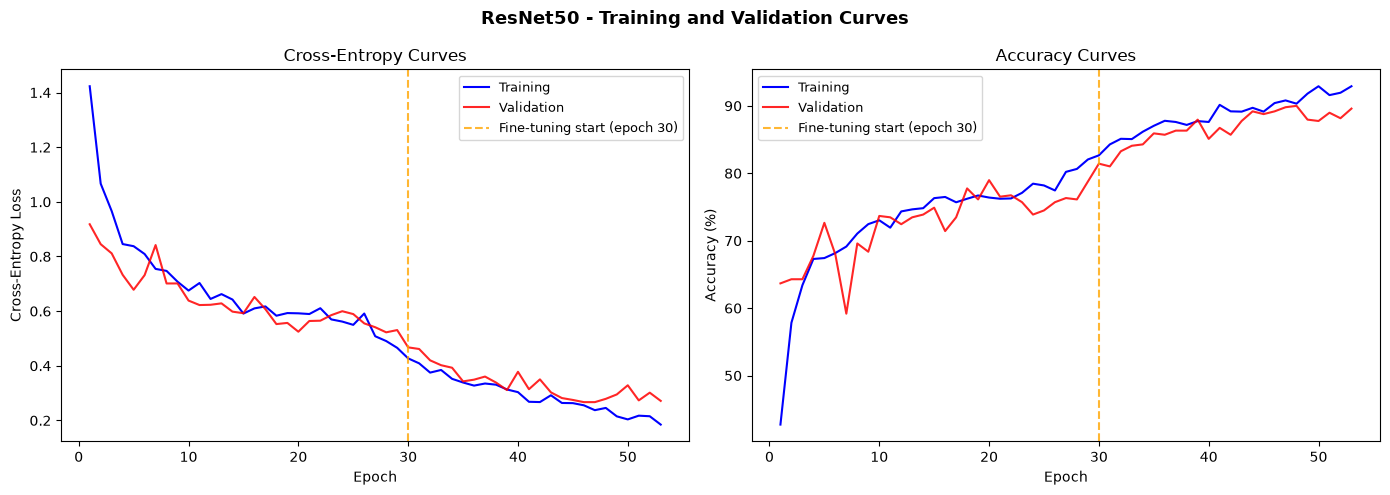

In [21]:
# ==============================================================================
# LEARNING CURVES VISUALISATION (TRAIN VS VALIDATION ACROSS BOTH PHASES)
# ==============================================================================
epochs_trained = len(history['train_loss'])
epochs_ran     = range(1, epochs_trained + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{MODEL_NAME} - Training and Validation Curves', fontsize=13, fontweight='bold')

# Subplot 1: Categorical Cross-Entropy Loss
# Subplot 2: Classification Accuracy (%)
for ax, tr_key, va_key, ylabel in [
    (axes[0], 'train_loss', 'val_loss', 'Cross-Entropy Loss'),
    (axes[1], 'train_acc',  'val_acc',  'Accuracy (%)'),
]:
    ytr = history[tr_key] if 'loss' in tr_key else [v * 100 for v in history[tr_key]]
    yva = history[va_key] if 'loss' in va_key else [v * 100 for v in history[va_key]]

    ax.plot(epochs_ran, ytr, 'b-', linewidth=1.5, label='Training')
    ax.plot(epochs_ran, yva, 'r-', linewidth=1.5, label='Validation', alpha=0.85)

    # Indicate transition point between Phase 1 and Phase 2 fine-tuning
    if epochs_trained > PHASE1_EPOCHS:
        ax.axvline(PHASE1_EPOCHS, color='orange', linestyle='--', linewidth=1.5, alpha=0.8,
                   label=f'Fine-tuning start (epoch {PHASE1_EPOCHS})')

    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel.split(" ")[0]} Curves')
    ax.legend(fontsize=9)

plt.tight_layout()
# Save high-resolution plot for report inclusion
plt.savefig(RES_DIR / f'{MODEL_NAME}_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()


## Section 8: Test Set Evaluation

In [22]:
# ==============================================================================
# COMPREHENSIVE CLINICAL TEST SET EVALUATION
# ==============================================================================
# Reload the global optimal checkpoint (lowest validation loss across both phases)
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

# Disable gradient calculation for pure inference
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(DEVICE))
        # Compute softmax probabilities over 4 classes: P(y=c | x) = exp(z_c) / sum(exp(z_j))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ==============================================================================
# MULTI-DIMENSIONAL PERFORMANCE METRICS CALCULATION
# ==============================================================================
# Overall Classification Accuracy
test_acc         = accuracy_score(all_labels, all_preds)

# Weighted Precision, Recall (Sensitivity), and F1-Score
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

# Multi-class One-vs-Rest (OvR) Area Under the ROC Curve
roc_auc          = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')

# Total Parameter Count
total_p          = sum(p.numel() for p in model.parameters())

# Per-Class Accuracy breakdown
per_class_acc    = [accuracy_score(all_labels[all_labels == i], all_preds[all_labels == i])
                    for i in range(NUM_CLASSES)]

print('=' * 55)
print(f'  {MODEL_NAME} - Final Test Set Results')
print('=' * 55)
print(f'  Accuracy  (weighted) : {test_acc*100:.2f}%')
print(f'  Precision (weighted) : {prec*100:.2f}%')
print(f'  Recall    (weighted) : {rec*100:.2f}%')
print(f'  F1-Score  (weighted) : {f1*100:.2f}%')
print(f'  ROC-AUC   (OvR,wtd) : {roc_auc:.4f}')
print(f'  Total parameters     : {total_p:,}')
print('=' * 55)
print('\nPer-Class Classification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=[c.replace('_', ' ').title() for c in CLASS_NAMES],
    digits=4
))


  ResNet50 - Final Test Set Results
  Accuracy  (weighted) : 87.76%
  Precision (weighted) : 87.80%
  Recall    (weighted) : 87.76%
  F1-Score  (weighted) : 87.61%
  ROC-AUC   (OvR,wtd) : 0.9788
  Total parameters     : 24,690,500

Per-Class Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor     0.8971    0.8777    0.8873       139
Meningioma Tumor     0.8425    0.7589    0.7985       141
        No Tumor     0.8202    0.9733    0.8902        75
 Pituitary Tumor     0.9275    0.9481    0.9377       135

        accuracy                         0.8776       490
       macro avg     0.8718    0.8895    0.8784       490
    weighted avg     0.8780    0.8776    0.8761       490



## Section 9: Confusion Matrix and ROC Curves

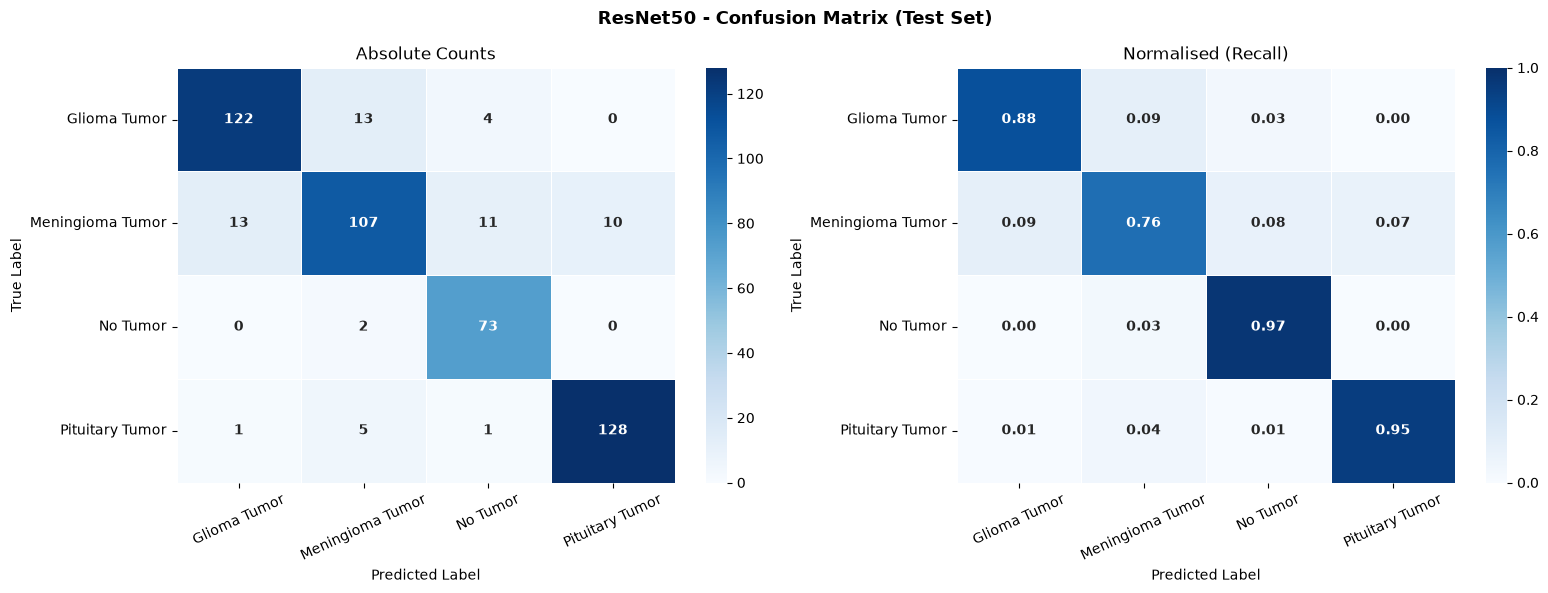

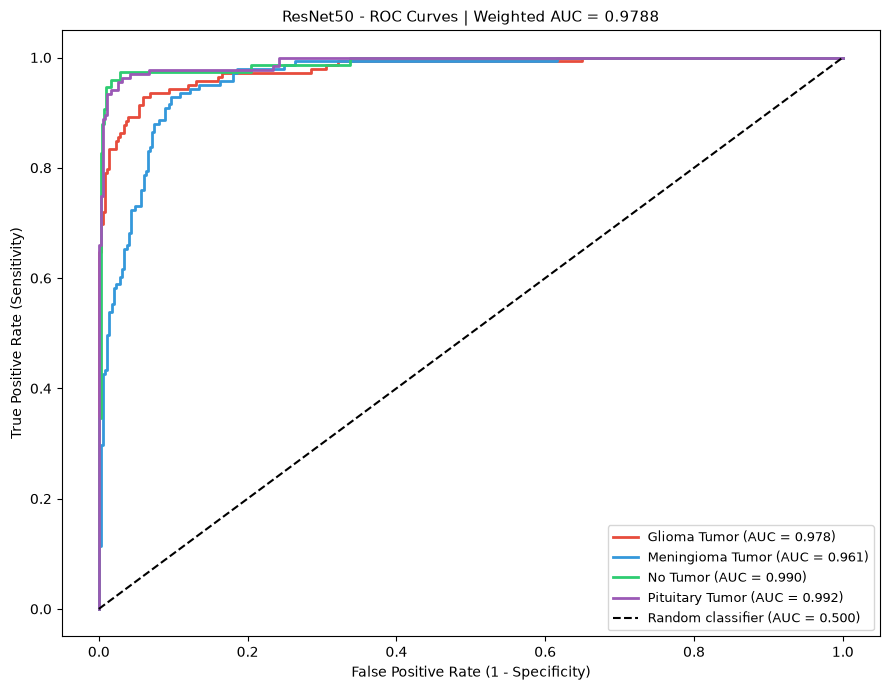

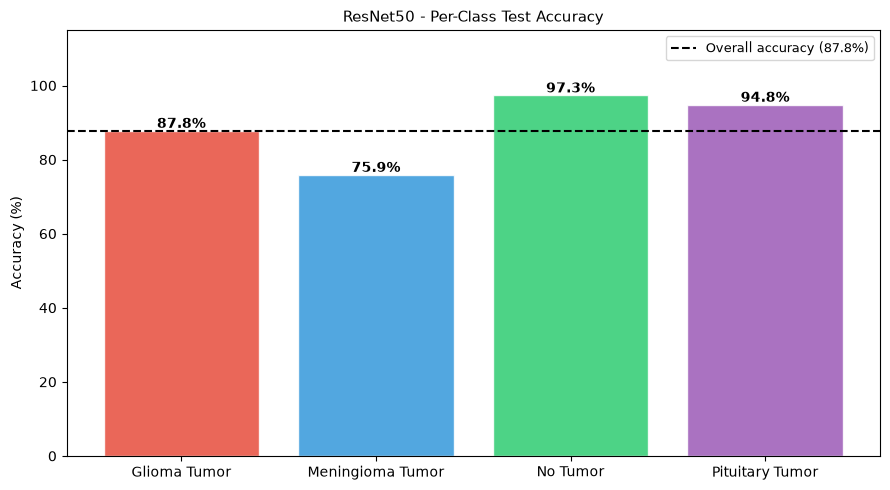

In [23]:
# ==============================================================================
# 1. CONFUSION MATRIX VISUALISATION (COUNTS AND NORMALISED FREQUENCIES)
# ==============================================================================
# Computes raw count confusion matrix
cm      = confusion_matrix(all_labels, all_preds)
# Normalises by true class totals (row sums) to display per-class sensitivity along the diagonal
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
pretty  = [c.replace('_', ' ').title() for c in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{MODEL_NAME} - Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

for ax, data, fmt, title, vmax in [
    (axes[0], cm,      'd',   'Absolute Counts', None),
    (axes[1], cm_norm, '.2f', 'Normalised (Recall)', 1.0),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=pretty, yticklabels=pretty,
                linewidths=0.5, vmin=0, vmax=vmax,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=25)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(RES_DIR / f'{MODEL_NAME}_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# ==============================================================================
# 2. MULTI-CLASS ONE-VS-REST (OvR) ROC CURVES
# ==============================================================================
# Binarize labels into one-hot encoding for multi-class ROC calculation
y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
for idx, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, _ = roc_curve(y_bin[:, idx], all_probs[:, idx])
    class_auc   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls.replace("_", " ").title()} (AUC = {class_auc:.3f})')

# Random chance benchmark line (diagonal 45-degree)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title(f'{MODEL_NAME} - ROC Curves | Weighted AUC = {roc_auc:.4f}', fontsize=11)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(RES_DIR / f'{MODEL_NAME}_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

# ==============================================================================
# 3. PER-CLASS ACCURACY BAR CHART
# ==============================================================================
per_class_acc_pct = [a * 100 for a in per_class_acc]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(pretty, per_class_acc_pct, color=CLASS_COLORS, alpha=0.85, edgecolor='white')
ax.axhline(test_acc * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall accuracy ({test_acc*100:.1f}%)')

# Annotate each bar with its exact percentage
for bar, val in zip(bars, per_class_acc_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'{MODEL_NAME} - Per-Class Test Accuracy', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RES_DIR / f'{MODEL_NAME}_per_class_accuracy.png', bbox_inches='tight', dpi=150)
plt.show()


## Section 10: Save Metrics

In [24]:
# ==============================================================================
# PERSIST METRICS TO JSON FOR CROSS-MODEL COMPARISON (NOTEBOOK 07)
# ==============================================================================
# Generate structured dictionary containing precision, recall, and f1 for every class
report_dict = classification_report(
    all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True
)

# Comprehensive metrics schema consumed by 07_Model_Comparison.ipynb
metrics = {
    'model_name':         MODEL_NAME,
    'architecture_type':  'ResNet50 Transfer Learning (ImageNet pretrained)',
    'test_accuracy':      float(test_acc),
    'weighted_precision': float(prec),
    'weighted_recall':    float(rec),
    'weighted_f1':        float(f1),
    'roc_auc_weighted':   float(roc_auc),
    'per_class_accuracy': {CLASS_NAMES[i]: float(per_class_acc[i]) for i in range(NUM_CLASSES)},
    'per_class_report':   report_dict,
    'total_params':       total_p,
    'epochs_trained':     epochs_trained,
    'fine_tuning':        True,
    'pretrained':         True,
    'pretrained_on':      'ImageNet-1K',
    'unfreeze_strategy':  'layer4 (final bottleneck stage, 2048 channels)',
    'hyperparameters': {
        'batch_size':    BATCH_SIZE,
        'lr_phase1':     LR_PHASE1,
        'lr_phase2':     LR_PHASE2,
        'normalization': 'ResNet50 ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])',
    },
}

# Save metrics JSON artifact
with open(RES_DIR / f'{MODEL_NAME}_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Metrics saved to results/{MODEL_NAME}_metrics.json')
print(f'Summary: Accuracy={test_acc*100:.2f}% | F1={f1*100:.2f}% | AUC={roc_auc:.4f} | Params={total_p:,}')


Metrics saved to results/ResNet50_metrics.json
Summary: Accuracy=87.76% | F1=87.61% | AUC=0.9788 | Params=24,690,500
